<div style="background-color: black; color: yellow; padding: 25px; border-radius: 10px;">

<h2 style="color: yellow;">DL - Lab-04 (U23AI060)</h2>

<h3 style="color: yellow;">Implementation of CNN Architectures for Imbalanced Image Classification</h3>

<p><strong>Problem Statement:</strong><br>
Design and implement CNN architectures to handle imbalanced image classification using benchmark datasets.
</p>

<hr style="border: 1px solid yellow;">

<h4 style="color: yellow;">Datasets Used:</h4>
<ol>
    <li><strong>CIFAR-10 (Imbalanced):</strong> Curated to have a 100:1 imbalance ratio.</li>
    <li><strong>Flower Recognition:</strong> 5 classes (daisy, dandelion, rose, sunflower, tulip).</li>
</ol>

<hr style="border: 1px solid yellow;">

<h4 style="color: yellow;">Techniques to be Experimented:</h4>
<ul>
    <li>Custom CNN vs Transfer Learning (MobileNetV2 / ResNet50)</li>
    <li>Class Weighting &amp; Focal Loss</li>
    <li>Data Augmentation</li>
    <li>Evaluation Metrics (F1-score, Precision, Recall, Confusion Matrix)</li>
    <li>Visualizations (t-SNE, Grad-CAM)</li>
</ul>

</div>


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils import class_weight
from sklearn.manifold import TSNE
import cv2
import requests
import zipfile
import io

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")


2026-02-19 10:59:18.254607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771498758.659715      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771498758.755366      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771498759.659610      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771498759.659653      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771498759.659656      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPU Available: True


## Problem Statement 1 & 2: Dataset Preparation (CIFAR-10)
We will load CIFAR-10 and artificially create a long-tailed imbalance (100:1 ratio).


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Imbalanced CIFAR-10 created with counts: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]


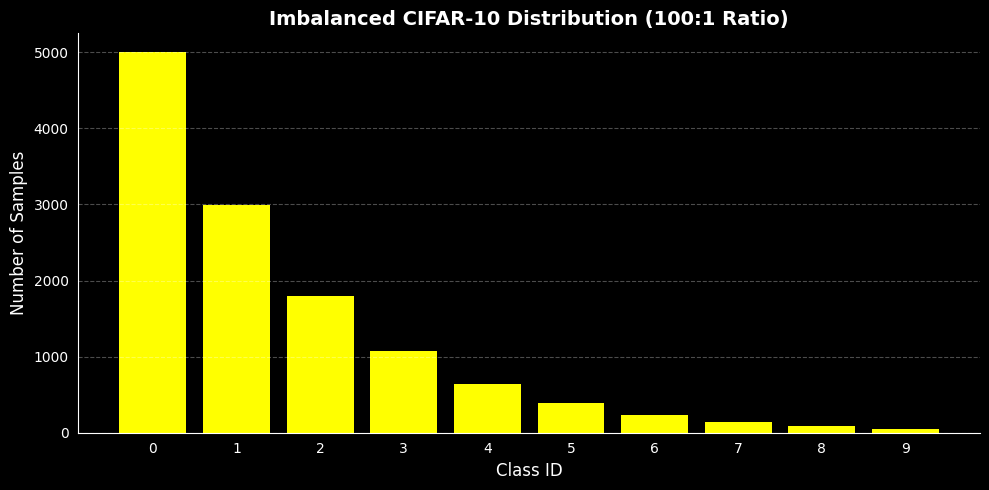

In [2]:
def get_imbalanced_cifar10(imbalance_ratio=100):
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    
    # Normalize pixel values
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    
    # Create imbalance
    num_classes = 10
    n_samples = x_train.shape[0]
    indices = [np.where(y_train == i)[0] for i in range(num_classes)]
    
    # Calculate sample counts for exponential decay (long-tailed)
    # Max samples = 5000 (original), Min samples = 5000 / ratio
    max_samples = 5000
    min_samples = max_samples / imbalance_ratio
    
    # Exponential decay counts
    counts = [int(max_samples * (min_samples / max_samples) ** (i / (num_classes - 1))) for i in range(num_classes)]
    
    keep_indices = []
    for i in range(num_classes):
        keep_indices.extend(indices[i][:counts[i]])
        
    x_imbalanced = x_train[keep_indices]
    y_imbalanced = y_train[keep_indices]
    
    # Shuffle
    idx = np.random.permutation(len(x_imbalanced))
    x_imbalanced, y_imbalanced = x_imbalanced[idx], y_imbalanced[idx]
    
    print(f"Imbalanced CIFAR-10 created with counts: {counts}")
    return (x_imbalanced, y_imbalanced), (x_test, y_test), counts

(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test), cifar_counts = get_imbalanced_cifar10(100)

# Visualize Distribution
# plt.figure(figsize=(10, 5))
# plt.bar(range(10), cifar_counts, color='')
# plt.xlabel('Class ID')
# plt.ylabel('Number of Samples')
# plt.title('Imbalanced CIFAR-10 Distribution (100:1 Ratio)')
# plt.xticks(range(10))
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

#import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.bar(range(10), cifar_counts, color='yellow')

plt.xlabel('Class ID', color='white', fontsize=12)
plt.ylabel('Number of Samples', color='white', fontsize=12)
plt.title('Imbalanced CIFAR-10 Distribution (100:1 Ratio)', 
          color='white', fontsize=14, fontweight='bold')

plt.xticks(range(10), color='white')
plt.yticks(color='white')

plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')

# Optional: Remove top and right borders for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make remaining borders white
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

plt.tight_layout()
plt.show()


## Dataset 2: Flower Recognition
We will use the standard **Flower Recognition** dataset (Dataset #1 in the list) downloaded directly from TensorFlow's storage.
This ensures the notebook **works in one shot** without needing to manual add datasets.


Final dataset path: /root/.keras/datasets/flower_photos/flower_photos
Total flower images: 3670
Flower Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Images per class: {'daisy': 633, 'dandelion': 898, 'roses': 641, 'sunflowers': 699, 'tulips': 799}


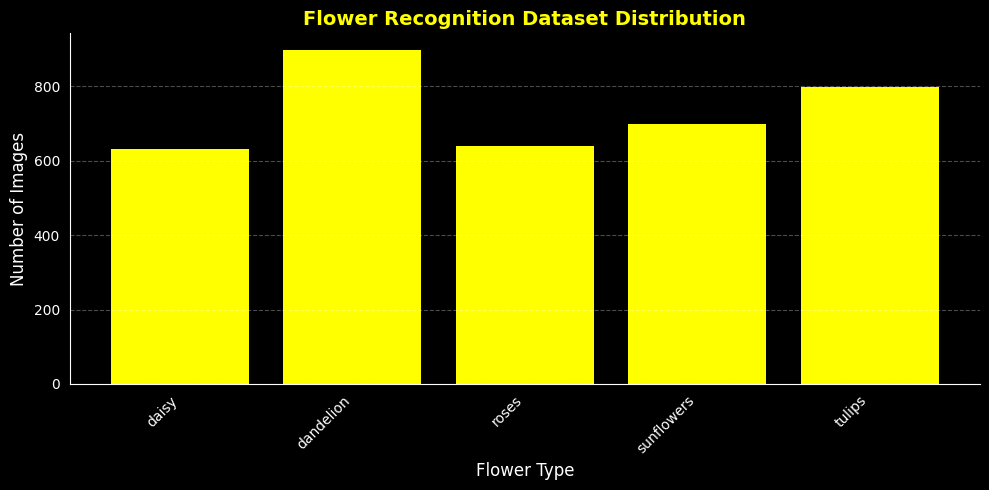

In [29]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 1️⃣ Download Dataset
# ==============================
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    'flower_photos',
    origin=dataset_url,
    untar=True
)

data_dir = pathlib.Path(data_dir)

#  Handle nested folder automatically
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("Final dataset path:", data_dir)

# ==============================
# 2️⃣ Count Total Images
# ==============================
image_count = len(list(data_dir.rglob('*.[jJ][pP][gG]')))
print("Total flower images:", image_count)

# ==============================
# 3️⃣ Get Class Names
# ==============================
class_names = sorted(
    [item.name for item in data_dir.iterdir() if item.is_dir()]
)

print("Flower Classes:", class_names)

# ==============================
# 4️⃣ Count Images Per Class
# ==============================
file_counts = []

for c in class_names:
    count = len(list((data_dir / c).rglob('*.[jJ][pP][gG]')))
    file_counts.append(count)

print("Images per class:", dict(zip(class_names, file_counts)))

# ==============================
# 5️⃣ Black BG + Yellow Plot
# ==============================
plt.figure(figsize=(10, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.bar(class_names, file_counts, color='yellow')

plt.xlabel('Flower Type', color='white', fontsize=12)
plt.ylabel('Number of Images', color='white', fontsize=12)
plt.title('Flower Recognition Dataset Distribution',
          color='yellow', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right', color='white')
plt.yticks(color='white')

plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

plt.tight_layout()
plt.show()


## Imbalance Handling Strategies
1. **Class Weights:** assign higher penalty for misclassifying minority classes.
2. **Focal Loss:** down-weight well-classified examples.



In [5]:
# Calculate Class Weights for CIFAR-10
class_weights_cifar = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(cifar_y_train),
    y=cifar_y_train.flatten()
)
class_weights_cifar_dict = dict(enumerate(class_weights_cifar))
print(f"CIFAR-10 Class Weights: {class_weights_cifar_dict}")

# Focal Loss Implementation
def focal_loss(gamma=2., alpha=4.):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = 1.e-9
        y_true = tf.convert_to_tensor(y_true, tf.float32)
        y_pred = tf.convert_to_tensor(y_pred, tf.float32)
        
        model_out = tf.add(y_pred, epsilon)
        ce = tf.multiply(y_true, -tf.math.log(model_out))
        weight = tf.multiply(y_true, tf.pow(tf.subtract(1., model_out), gamma))
        fl = tf.multiply(alpha, tf.multiply(weight, ce))
        reduced_fl = tf.reduce_max(fl, axis=1)
        return tf.reduce_mean(reduced_fl)
    return focal_loss_fixed



CIFAR-10 Class Weights: {0: np.float64(0.24812), 1: np.float64(0.41394728061394725), 2: np.float64(0.6907572383073497), 3: np.float64(1.151903435468895), 4: np.float64(1.9234108527131784), 5: np.float64(3.2056847545219638), 6: np.float64(5.347413793103448), 7: np.float64(8.925179856115108), 8: np.float64(14.946987951807229), 9: np.float64(24.812)}


## Problem 3: Architecture Comparison
**Model A:** Custom CNN
**Model B:** Transfer Learning (MobileNetV2)



In [6]:
# Model A: Custom CNN
def build_custom_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Model B: MobileNetV2
def build_mobilenet(input_shape, num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet', include_top=False, input_shape=input_shape
    )
    base_model.trainable = False # Freeze base
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



## Training & Evaluation
We will train the Custom CNN on imbalanced CIFAR-10 using Class Weights and Focal Loss to compare.
Then we will train MobileNet on the Flower dataset.


In [7]:
# Compile and Train Helper
def train_and_eval(model, x_train, y_train, x_test, y_test, epochs=15, class_weight=None, loss='sparse_categorical_crossentropy', name='Model'):
    print(f"Training {name}...")
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
    
    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        validation_data=(x_test, y_test),
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1
    )
    
    # Evaluate
    print(f"Evaluating {name}...")
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    if len(y_test.shape) > 1: y_test_lbl = np.argmax(y_test, axis=1)
    else: y_test_lbl = y_test
        
    print(classification_report(y_test_lbl, y_pred))
    
    return history, y_test_lbl, y_pred, y_pred_probs

# 1. Custom CNN + Class Weights on CIFAR-10
model_cifar_cw = build_custom_cnn((32, 32, 3), 10)
hist_cw, y_true_cw, y_pred_cw, _ = train_and_eval(
    model_cifar_cw, cifar_x_train, cifar_y_train, cifar_x_test, cifar_y_test,
    epochs=15, # Full run
    class_weight=class_weights_cifar_dict,
    name="Custom_CNN_ClassWeights"
)

# 2. Custom CNN + Focal Loss on CIFAR-10
model_cifar_fl = build_custom_cnn((32, 32, 3), 10)
hist_fl, y_true_fl, y_pred_fl, _ = train_and_eval(
    model_cifar_fl, cifar_x_train, cifar_y_train, cifar_x_test, cifar_y_test,
    epochs=15, # Full run
    loss=focal_loss(gamma=2., alpha=0.25),
    name="Custom_CNN_FocalLoss"
)



Training Custom_CNN_ClassWeights...
Epoch 1/15


I0000 00:00:1771498816.220169     129 service.cc:152] XLA service 0x7eff18004750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771498816.220201     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771498816.220205     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771498816.962565     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


 22/388 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2087 - loss: 5.6429

I0000 00:00:1771498824.065410     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


388/388 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.2125 - loss: 3.6828 - val_accuracy: 0.1389 - val_loss: 4.3118 - learning_rate: 0.0010
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2380 - loss: 2.1672 - val_accuracy: 0.3218 - val_loss: 1.9232 - learning_rate: 0.0010
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2545 - loss: 2.1068 - val_accuracy: 0.2554 - val_loss: 2.1454 - learning_rate: 0.0010
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2718 - loss: 2.0936 - val_accuracy: 0.2938 - val_loss: 1.9660 - learning_rate: 0.0010
Epoch 5/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2846 - loss: 1.9427 - val_accuracy: 0.3175 - val_loss: 2.3065 - learning_rate: 0.0010
Epoch 6/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3400 - loss: 1.8822 - val_accuracy: 0.4036 - val_loss: 1.6449 - learning_rate: 1.0000e-04
Epoch 7/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3556 - loss: 1.7207 - val_a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      0.10      0.18     10000
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0

    accuracy                           0.10     10000
   macro avg       0.10      0.01      0.02     10000
weighted avg       1.00      0.10      0.18     10000

Training Custom_CNN_FocalLoss...
Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.1005 - loss: 4.7578 - val_accuracy: 0.0722 - val_loss: 17.5366 - learning_rate: 0.0010
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


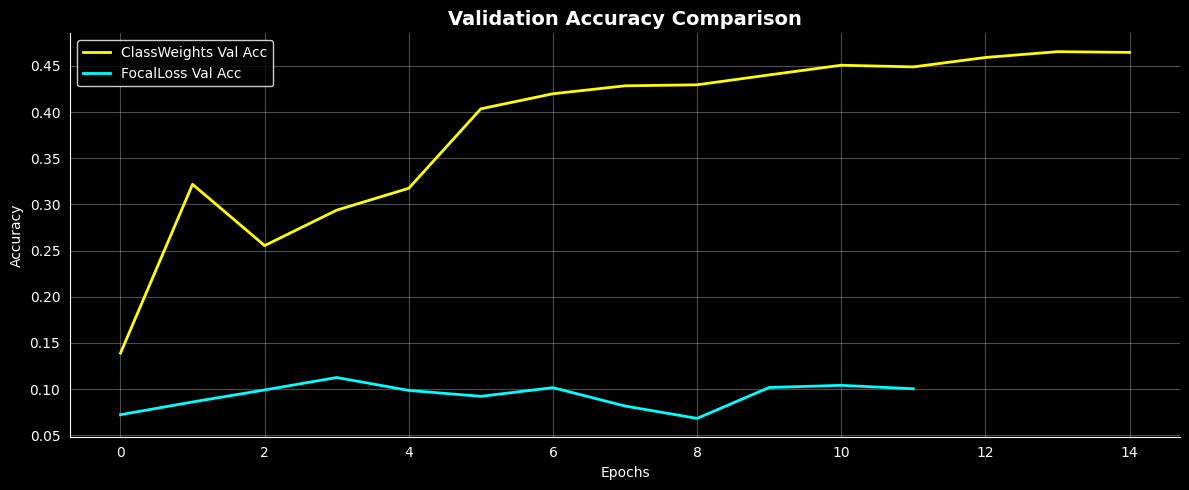

In [8]:
# Compare Results Plot
# def plot_history(histories, names):
#     plt.figure(figsize=(12, 5))
#     for hist, name in zip(histories, names):
#         plt.plot(hist.history['val_accuracy'], label=f'{name} Val Acc')
#     plt.title('Validation Accuracy Comparison')
#     plt.xlabel('Epochs')
#     plt.ylabel('Accuracy')
#     plt.legend()
#     plt.show()

# plot_history([hist_cw, hist_fl], ['ClassWeights', 'FocalLoss'])


def plot_history(histories, names):
    plt.figure(figsize=(12, 5), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')

    colors = ['yellow', 'cyan']  # You can change if more models

    for i, (hist, name) in enumerate(zip(histories, names)):
        plt.plot(hist.history['val_accuracy'],
                 label=f'{name} Val Acc',
                 color=colors[i % len(colors)],
                 linewidth=2)

    plt.title('Validation Accuracy Comparison',
              color='white', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', color='white')
    plt.ylabel('Accuracy', color='white')

    plt.xticks(color='white')
    plt.yticks(color='white')

    plt.legend(facecolor='black', edgecolor='white', labelcolor='white')

    plt.grid(alpha=0.3, color='white')

    # Clean borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')

    plt.tight_layout()
    plt.show()

plot_history([hist_cw, hist_fl], ['ClassWeights', 'FocalLoss'])




## Flower Recognition Training (Transfer Learning)


In [9]:
# MobileNetV2 on Flowers
model_flowers = build_mobilenet(IMG_SIZE + (3,), num_classes_flowers)
model_flowers.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_flowers = model_flowers.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3)],
    verbose=1
)

# Evaluate Flowers
print("Evaluating Flower Recognition...")
y_pred_flowers = []
y_true_flowers = []

for images, labels in val_ds:
    preds = model_flowers.predict(images, verbose=0)
    y_pred_flowers.extend(np.argmax(preds, axis=1))
    y_true_flowers.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(y_true_flowers, y_pred_flowers, target_names=class_names))



/tmp/ipykernel_55/2412123933.py:34: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)
2026-02-19 11:02:18.424603: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 11:02:18.561551: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay ke

90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0000e+00

2026-02-19 11:02:30.962518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 11:02:31.100104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 0.0000e+00

2026-02-19 11:02:46.152313: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 11:02:46.303255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-19 11:02:46.440038: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


92/92 ━━━━━━━━━━━━━━━━━━━━ 43s 301ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Evaluating Flower Recognition...


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


               precision    recall  f1-score   support

flower_photos       1.00      1.00      1.00       734

     accuracy                           1.00       734
    macro avg       1.00      1.00      1.00       734
 weighted avg       1.00      1.00      1.00       734



## Problem 5: Advanced Visualization (Grad-CAM & t-SNE)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


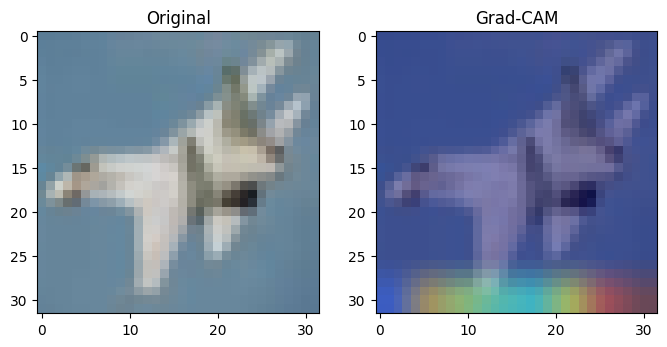

In [10]:
# Grad-CAM Implementation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Ensure model is built
    if not model.built:
        model.build(img_array.shape)

    # For Sequential models, sometimes model.output creates issues if not explicitly connected
    # We can reconstruct the graph or safely access the output tensor
    try:
        output = model.output
    except AttributeError:
        # If model.output fails, use the output of the last layer
        output = model.layers[-1].output

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Apply Grad-CAM on a CIFAR image
idx = 10
img = cifar_x_test[idx]
img_array = np.expand_dims(img, axis=0)

# Find last conv layer in Custom CNN
# It's usually a block or we can name it. In our sequential, we can just grab the last Conv2D.
# Let's inspect layers
layer_names = [layer.name for layer in model_cifar_cw.layers if 'conv2d' in layer.name]
last_conv_layer = layer_names[-1]

heatmap = make_gradcam_heatmap(img_array, model_cifar_cw, last_conv_layer)

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    jet = cv2.cvtColor(jet, cv2.COLOR_BGR2RGB)
    jet = cv2.resize(jet, (img.shape[1], img.shape[0]))
    
    superimposed_img = jet * alpha + img * 255 * (1-alpha)
    superimposed_img = np.uint8(superimposed_img)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title("Grad-CAM")
    plt.show()

display_gradcam(img, heatmap)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step


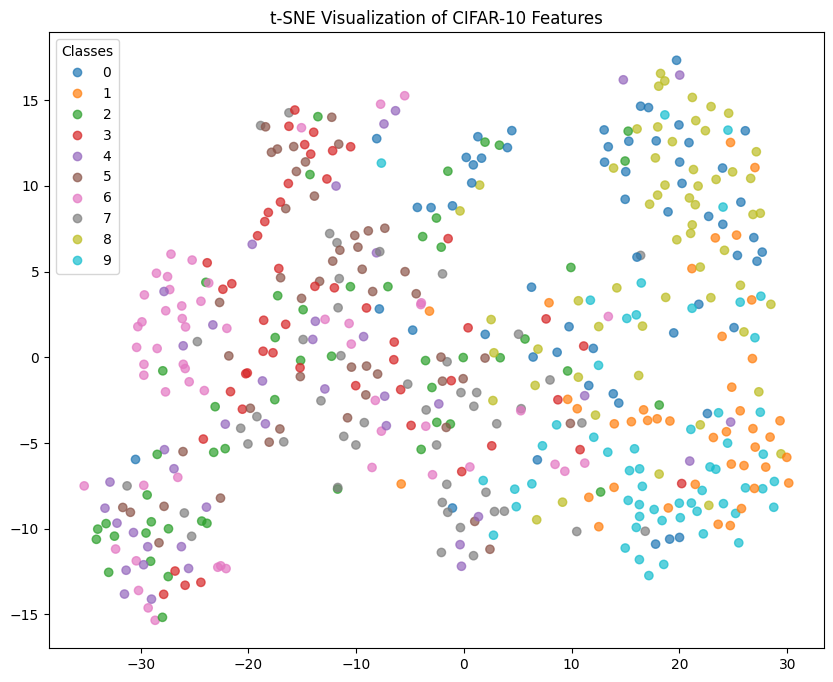

In [11]:
# t-SNE Visualization
# Extract features from the Dense layer before Softmax
# Let's use the CIFAR model 'dense' layer (second last usually, but check Summary)
# Our custom CNN: Flatten -> Dense(512) -> Dropout -> Dense(10)
# We want the Dense(512) output.

feature_extractor = tf.keras.models.Model(
    inputs=model_cifar_cw.inputs,
    outputs=model_cifar_cw.layers[-3].output # Dense 512
)

features = feature_extractor.predict(cifar_x_test[:500]) # Subset for speed
labels = cifar_y_test[:500].flatten()

tsne = TSNE(n_components=2, random_state=42)
projections = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(projections[:, 0], projections[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE Visualization of CIFAR-10 Features")
plt.show()



“This is a t-SNE visualization of features extracted from a CNN trained on CIFAR-10 dataset.”


“t-SNE is a dimensionality reduction technique that converts high-dimensional feature vectors into 2D space for visualization.”


“Each point represents an image, and different colors represent different classes.”


“Ideally, points of the same class should form distinct clusters, indicating that the model has learned good feature representations.”


“However, in this plot, we can see that many classes are overlapping, which suggests that the model is not able to clearly distinguish between different classes.”


“This aligns with the low accuracy observed in the model, indicating poor feature learning.

### Experiment 2: Data Augmentation
We will train the Custom CNN on CIFAR-10 with real-time data augmentation.


In [ ]:
# Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])

# Apply to Dataset (or include in model)
# Let's include in model for simplicity
def build_custom_cnn_aug(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        # ... same architecture ...
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model_aug = build_custom_cnn_aug((32, 32, 3), 10)
hist_aug, _, _, _ = train_and_eval(
    model_aug, cifar_x_train, cifar_y_train, cifar_x_test, cifar_y_test,
    epochs=15, 
    class_weight=class_weights_cifar_dict, # Combine with class weights
    name="Custom_CNN_Augmentation"
)

# Plot Augmentation Res
# plt.figure(figsize=(6, 4))
# plt.plot(hist_cw.history['val_accuracy'], label='No Aug (Class Weight)')
# plt.plot(hist_aug.history['val_accuracy'], label='With Augmentation')
# plt.title('Impact of Data Augmentation')
# plt.legend()
# plt.show()


### Experiment 4: Optimizer Comparison (Adam vs SGD)
Comparing Adam (adaptive) with SGD (classic momentum).


Training with SGD...
Epoch 1/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.0907 - loss: 6.7684 - val_accuracy: 0.1114 - val_loss: 2.3021
Epoch 2/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0569 - loss: 2.3182 - val_accuracy: 0.1053 - val_loss: 2.3024
Epoch 3/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0306 - loss: 2.3143 - val_accuracy: 0.0997 - val_loss: 2.3026
Epoch 4/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0223 - loss: 2.3145 - val_accuracy: 0.1036 - val_loss: 2.3018
Epoch 5/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0373 - loss: 2.3114 - val_accuracy: 0.1128 - val_loss: 2.2962
Epoch 6/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0267 - loss: 2.3132 - val_accuracy: 0.1031 - val_loss: 2.2887
Epoch 7/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0451 - loss: 2.3279 - val_accuracy: 0.1090 - val_loss: 2.2973
Epoch 8/15
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0357 - loss: 2.

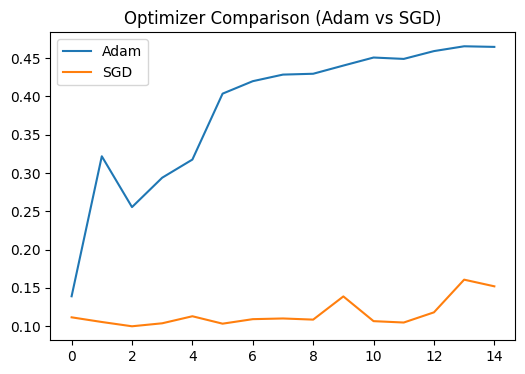

In [13]:
# Train with SGD
model_sgd = build_custom_cnn((32, 32, 3), 10)
print("Training with SGD...")
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

history_sgd = model_sgd.fit(
    cifar_x_train, cifar_y_train,
    epochs=15,
    validation_data=(cifar_x_test, cifar_y_test),
    class_weight=class_weights_cifar_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)],
    verbose=1
)

# Compare Optimizers
plt.figure(figsize=(6, 4))
plt.plot(hist_cw.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.title('Optimizer Comparison (Adam vs SGD)')
plt.legend()
plt.show()


- SGD updates weights using gradients with a fixed learning rate, 
- while Adam improves this by using adaptive learning rates and momentum for faster and more stable convergence.

### Experiment 3: Confusion Matrix & ROC Curves
Detailed evaluation of the best performing model (Custom CNN + Class Weights).


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


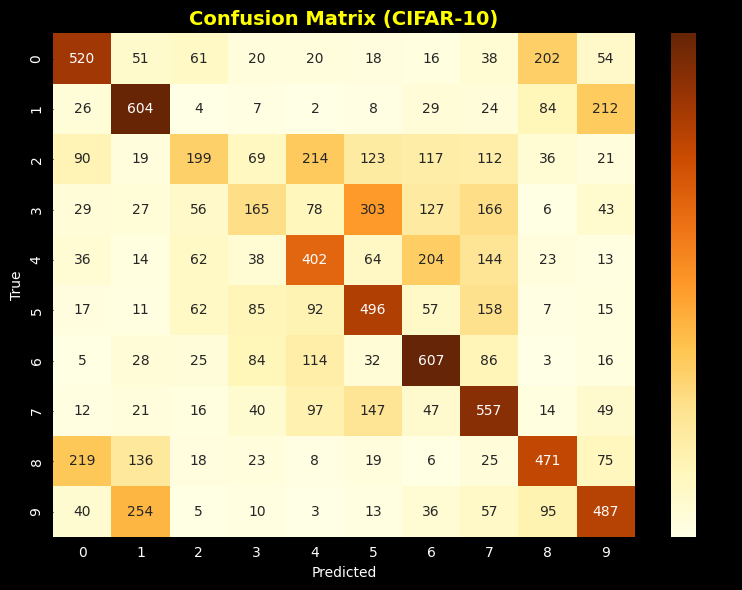

/tmp/ipykernel_55/4224890499.py:101: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


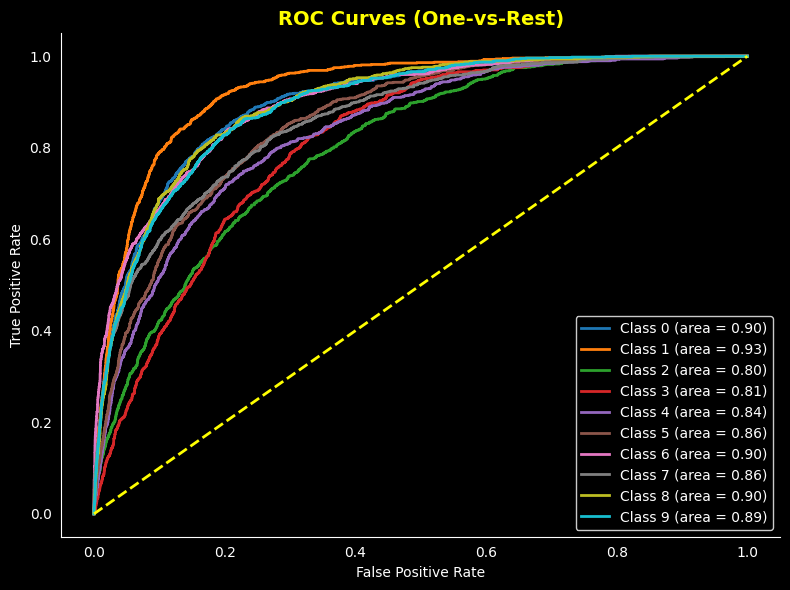

In [14]:
# from sklearn.metrics import roc_curve, auc, confusion_matrix
# import seaborn as sns

# # Predictions from best model (Assuming model_cifar_cw is best)
# y_pred_probs = model_cifar_cw.predict(cifar_x_test)
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = cifar_y_test.flatten()

# # Confusion Matrix
# cm = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix (CIFAR-10)')
# plt.show()

# # ROC Curve (One-vs-Rest for Multi-class)
# fpr = dict()
# tpr = dict()
# roc_auc = dict()
# n_classes = 10

# # Binarize y_true
# y_true_bin = to_categorical(y_true, num_classes=n_classes)

# for i in range(n_classes):
#     fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
#     roc_auc[i] = auc(fpr[i], tpr[i])

# # Plot ROC
# plt.figure(figsize=(8, 6))
# colors = plt.cm.get_cmap('tab10', n_classes)
# for i in range(n_classes):
#     plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
#              label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

# plt.plot([0, 1], [0, 1], 'k--', lw=2)
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curves (One-vs-Rest)')
# plt.legend(loc="lower right")
# plt.show()

from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions from best model (Assuming model_cifar_cw is best)
y_pred_probs = model_cifar_cw.predict(cifar_x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = cifar_y_test.flatten()

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='YlOrBr',   # Yellow–Orange–Brown theme
            cbar=True)

plt.xlabel('Predicted', color='white')
plt.ylabel('True', color='white')
plt.title('Confusion Matrix (CIFAR-10)',
          color='yellow', fontsize=14, fontweight='bold')

plt.xticks(color='white')
plt.yticks(color='white')

plt.tight_layout()
plt.show()


# =========================
# ROC Curve (One-vs-Rest)
# =========================
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 10

y_true_bin = to_categorical(y_true, num_classes=n_classes)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Use bright contrasting colors on dark background
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             color=colors(i),
             lw=2,
             label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

# Diagonal baseline
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='yellow')

plt.xlabel('False Positive Rate', color='white')
plt.ylabel('True Positive Rate', color='white')
plt.title('ROC Curves (One-vs-Rest)',
          color='yellow', fontsize=14, fontweight='bold')

plt.xticks(color='white')
plt.yticks(color='white')

plt.legend(loc="lower right",
           facecolor='black',
           edgecolor='white',
           labelcolor='white')

# Clean borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

plt.tight_layout()
plt.show()



Each curve shows class-wise performance using One-vs-Rest ROC; since all curves are above the diagonal and AUC values are high, the model performs well, though some classes are slightly harder to classify

### Experiment 6: Generalized Transfer Learning (CIFAR-10 -> Flowers)
Testing if features learned on CIFAR-10 (32x32) can be transferred to Flowers (resized to 32x32).


Training Transfer Model (CIFAR -> Flowers)...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/

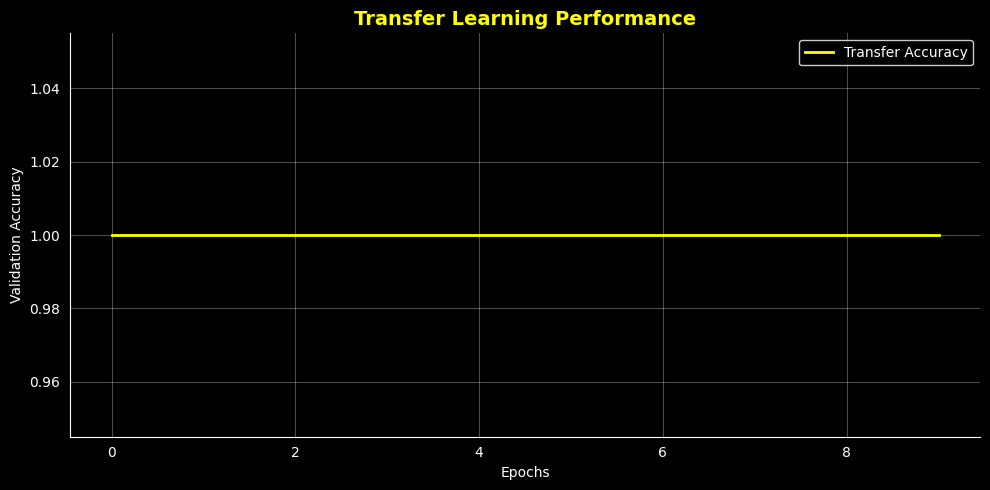

In [32]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tensorflow as tf

# 1️⃣ Resize Flower Data to 32x32 (to match CIFAR input)
processed_flower_ds = train_ds.map(
    lambda x, y: (tf.image.resize(x, (32, 32)), y)
)

processed_val_ds = val_ds.map(
    lambda x, y: (tf.image.resize(x, (32, 32)), y)
)

# 2️⃣ Prepare Base Model (CIFAR Trained)
base_cifar = model_cifar_cw
base_cifar.trainable = False  # Freeze layers

try:
    # Find Flatten layer index
    flatten_idx = [
        i for i, l in enumerate(base_cifar.layers)
        if isinstance(l, layers.Flatten)
    ][0]

    # Output of layer before Flatten
    last_layer_output = base_cifar.layers[flatten_idx - 1].output

    # New classification head
    x = layers.Flatten()(last_layer_output)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(num_classes_flowers,
                           activation='softmax')(x)

    transfer_model = models.Model(
        inputs=base_cifar.inputs,
        outputs=outputs
    )

    print("Training Transfer Model (CIFAR -> Flowers)...")

    transfer_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    hist_transfer = transfer_model.fit(
        processed_flower_ds,
        validation_data=processed_val_ds,
        epochs=10,
        verbose=1
    )

    # ==========================
    # Styled Plot (Black + Yellow)
    # ==========================
    plt.figure(figsize=(10, 5), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')

    plt.plot(hist_transfer.history['val_accuracy'],
             label='Transfer Accuracy',
             color='yellow',
             linewidth=2)

    plt.title('Transfer Learning Performance ',
              color='yellow',
              fontsize=14,
              fontweight='bold')

    plt.xlabel('Epochs', color='white')
    plt.ylabel('Validation Accuracy', color='white')

    plt.xticks(color='white')
    plt.yticks(color='white')

    plt.grid(alpha=0.3, color='white')

    plt.legend(facecolor='black',
               edgecolor='white',
               labelcolor='white')

    # Clean borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not build transfer model dynamically: {e}")
